# Linear V1 Inspection Notebook

This notebook is for interactive inspection of the current JAX implementation:
- `finit='cosine2'` initialization
- current linear solver stepping (`gksolve_with_state`)
- representative mode-growth diagnostics
- checkpoint comparison against `iteration_13_Lin` (`DM2 -> FDS`)

Run inside the mandated environment (`/system/apps/userenv/galletti/mhd`).

# Linear V1 Inspection Notebook

This notebook is for interactive inspection of the current JAX implementation:
- `finit='cosine2'` initialization
- current linear solver stepping (`gksolve_with_state`)
- representative mode-growth diagnostics
- checkpoint comparison against `iteration_13_Lin` (`DM2 -> FDS`)

Run inside the mandated environment (`/system/apps/userenv/galletti/mhd`).

In [1]:
import sys

sys.path.append("..")

In [2]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jax_geometry import load_geometry
from jax_integrals import get_integrals
from gksolver import GKParams, default_state, gksolve_with_state, init_df_cosine2
from utils import load_gkw_k_dump
from plot_utils import plot_nd

jax.config.update("jax_enable_x64", True)

BASE = "/restricteddata/ukaea/gyrokinetics/raw/iteration_13_Lin"
geom = load_geometry(BASE)

print("Loaded geometry from:", BASE)
print("Grid sizes (vpar, mu, s, kx, ky):", len(geom["intvp"]), len(geom["intmu"]), len(geom["ints"]), len(geom["kxrh"]), len(geom["krho"]))
print("ixzero, iyzero:", int(geom["ixzero"]), int(geom["iyzero"]))
print("kx range:", float(np.min(np.asarray(geom["kxrh"]))), float(np.max(np.asarray(geom["kxrh"]))))
print("ky range:", float(np.min(np.asarray(geom["krho"]))), float(np.max(np.asarray(geom["krho"]))))

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


Loaded geometry from: /restricteddata/ukaea/gyrokinetics/raw/iteration_13_Lin
Grid sizes (vpar, mu, s, kx, ky): 32 8 16 85 32
ixzero, iyzero: 42 0
kx range: -8.87631 8.87631
ky range: 0.0 0.4430323666789028


## 1) Inspect initialization (`finit='cosine2'`)

In [3]:
df0_raw = init_df_cosine2(geom, amp_init_real=1.0e-4, amp_init_imag=0.0, normalize_per_toroidal_mode=False)
df0 = init_df_cosine2(geom, amp_init_real=1.0e-4, amp_init_imag=0.0, normalize_per_toroidal_mode=True)

iyzero = int(geom["iyzero"])
print("df0_raw shape:", df0_raw.shape, "dtype:", df0_raw.dtype)
print("df0 (startup normalized) shape:", df0.shape)
print("max |df0_raw[..., ky=0]|:", float(jnp.max(jnp.abs(df0_raw[..., iyzero]))))
print("max |df0[..., ky=0]|:", float(jnp.max(jnp.abs(df0[..., iyzero]))))

# Verify startup mode normalization (non-zonal ky expected near 1).
phi0_raw, _ = get_integrals(df0_raw, geom)
phi0, _ = get_integrals(df0, geom)
ds = float(np.asarray(geom["ints"])[0])
amp_raw = np.sqrt(ds * np.sum(np.abs(np.asarray(phi0_raw))**2, axis=(0,1)))
amp_norm = np.sqrt(ds * np.sum(np.abs(np.asarray(phi0))**2, axis=(0,1)))
print("non-zonal min/max amp after startup normalization:", float(np.min(amp_norm[np.arange(len(amp_norm)) != iyzero])), float(np.max(amp_norm[np.arange(len(amp_norm)) != iyzero])))

df0_raw shape: (32, 8, 16, 85, 32) dtype: complex128
df0 (startup normalized) shape: (32, 8, 16, 85, 32)
max |df0_raw[..., ky=0]|: 0.0
max |df0[..., ky=0]|: 0.0
non-zonal min/max amp after startup normalization: 0.9999999999999991 1.0000000000000007


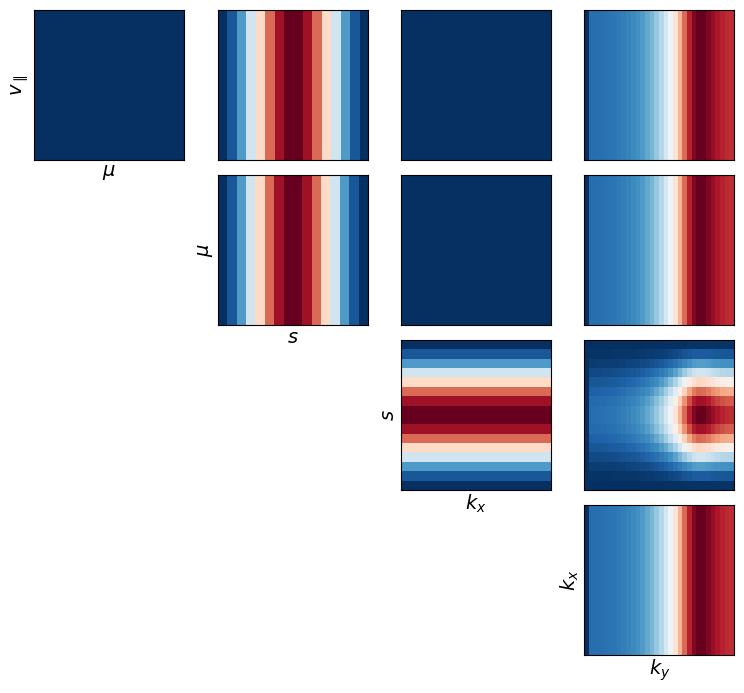

In [4]:
fig = plot_nd(np.abs(np.asarray(df0)))

## 2) Helper utilities for mode chains and stepping

In [5]:
mode_label = np.asarray(geom["mode_label"])
ixzero = int(geom["ixzero"])
iyzero = int(geom["iyzero"])

def connected_kx_indices(ky_index: int):
    lbl = int(mode_label[ixzero, ky_index])
    return np.where(mode_label[:, ky_index] == lbl)[0], lbl

def run_small_steps(df_init, nsteps=80, params=None):
    if params is None:
        params = GKParams(dt=0.01, naverage=40, disp_par=1.0, disp_x=0.1, disp_y=0.1)
    state = default_state()
    df = df_init
    phi_hist = []
    growth_hist = []
    for _ in range(nsteps):
        df, (phi, _), state = gksolve_with_state(df, geom, params, state)
        phi_hist.append(np.asarray(phi))
        growth_hist.append(float(np.asarray(state.last_growth_rate)))
    return df, np.asarray(phi_hist), np.asarray(growth_hist), state

## 3) Quick evolution from init and representative mode-growth visualization

Ran 80 small steps in 138.10s
state.step: 80 state.time: 0.8000000000000005 last_growth_rate: 0.23555975980835966


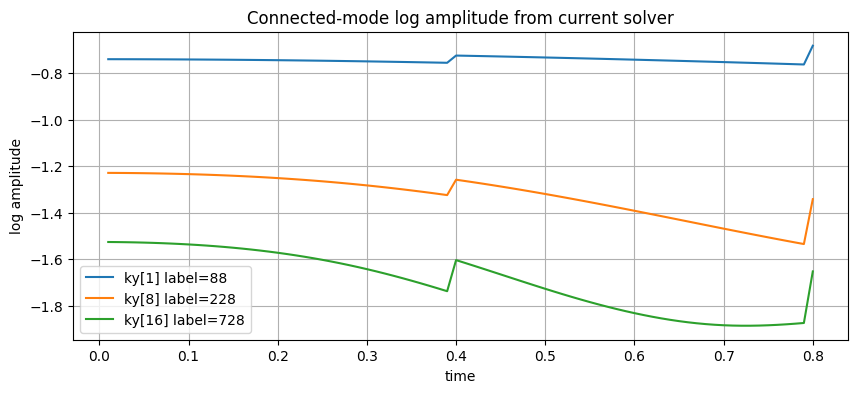

In [6]:
params = GKParams(dt=0.01, naverage=40, disp_par=1.0, disp_x=0.1, disp_y=0.1)
nsteps = 80

t0 = time.time()
df80, phi_hist, growth_hist, state80 = run_small_steps(df0, nsteps=nsteps, params=params)
print(f"Ran {nsteps} small steps in {time.time()-t0:.2f}s")
print("state.step:", int(np.asarray(state80.step)), "state.time:", float(np.asarray(state80.time)), "last_growth_rate:", float(np.asarray(state80.last_growth_rate)))

rep_ky = [1, 8, 16]
rep_ky = [k for k in rep_ky if k < len(geom["krho"]) and k != iyzero]

dt = params.dt
time_small = dt * np.arange(1, nsteps + 1)
ds = float(np.asarray(geom["ints"])[0])

plt.figure(figsize=(10, 4))
for ky in rep_ky:
    kx_chain, lbl = connected_kx_indices(ky)
    amp = np.sqrt(ds * np.sum(np.abs(phi_hist[:, :, kx_chain, ky])**2, axis=(1,2)))
    plt.plot(time_small, np.log(np.maximum(amp, 1e-30)), label=f"ky[{ky}] label={lbl}")
plt.xlabel("time")
plt.ylabel("log amplitude")
plt.title("Connected-mode log amplitude from current solver")
plt.legend()
plt.grid(True)
plt.show()

## 4) Evaluate against `iteration_13_Lin` checkpoints (`DM2 -> FDS`)

In [7]:
res = (len(geom["intvp"]), len(geom["intmu"]), len(geom["ints"]), len(geom["kxrh"]), len(geom["krho"]))
dm2 = load_gkw_k_dump(f"{BASE}/DM2", res)
fds = load_gkw_k_dump(f"{BASE}/FDS", res)

# DM2 at t=319.2, FDS at t=320.0 -> 80 small steps (dt=0.01)
t0 = time.time()
dm2_to_fds_pred, _, _, _ = run_small_steps(dm2, nsteps=80, params=params)
print(f"DM2->FDS prediction runtime: {time.time()-t0:.2f}s")

def rel_l2(a, b, eps=1e-30):
    na = float(jnp.linalg.norm(a - b))
    nb = float(jnp.linalg.norm(b))
    return na / max(nb, eps)

phi_pred, flux_pred = get_integrals(dm2_to_fds_pred, geom)
phi_fds, flux_fds = get_integrals(fds, geom)

print("Relative L2(df_pred, FDS):", rel_l2(dm2_to_fds_pred, fds))
print("Relative L2(phi_pred, phi_FDS):", rel_l2(phi_pred, phi_fds))

p_pred, e_pred, v_pred = [float(np.asarray(x)) for x in flux_pred]
p_ref, e_ref, v_ref = [float(np.asarray(x)) for x in flux_fds]
print("Fluxes pred (p,e,v):", p_pred, e_pred, v_pred)
print("Fluxes FDS  (p,e,v):", p_ref, e_ref, v_ref)
print("Relative flux errors:", abs(p_pred-p_ref)/(abs(p_ref)+1e-30), abs(e_pred-e_ref)/(abs(e_ref)+1e-30), abs(v_pred-v_ref)/(abs(v_ref)+1e-30))

DM2->FDS prediction runtime: 128.64s
Relative L2(df_pred, FDS): 8.909776831330476e-06
Relative L2(phi_pred, phi_FDS): 7.603481167641534e-06
Fluxes pred (p,e,v): 7.771561172376096e-16 38.29886473436173 9.259260025373806e-14
Fluxes FDS  (p,e,v): 6.661338147750939e-16 38.29877310593047 9.403589018575076e-14
Relative flux errors: 0.1666666666666664 2.39246387875708e-06 0.015348288075560802


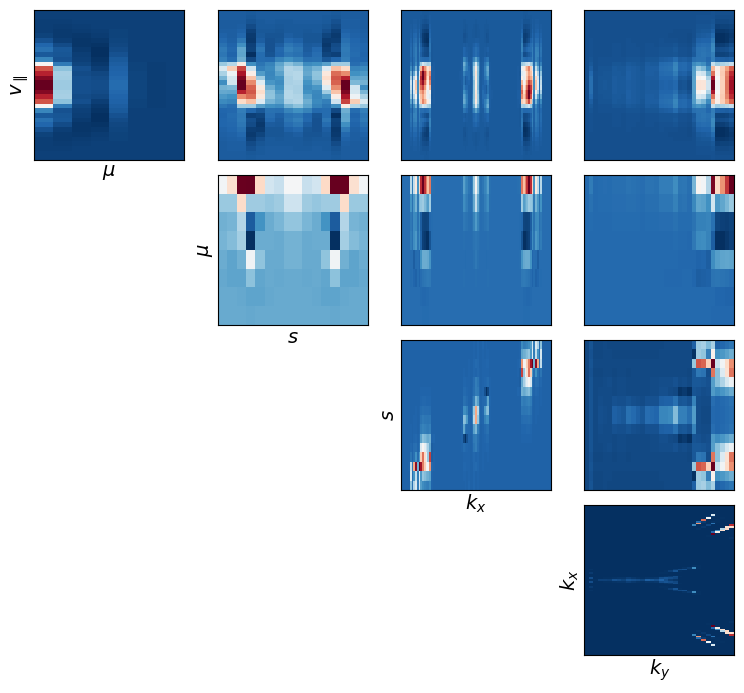

In [ ]:
fig = plot_nd(np.abs(np.asarray(dm2_to_fds_pred)))

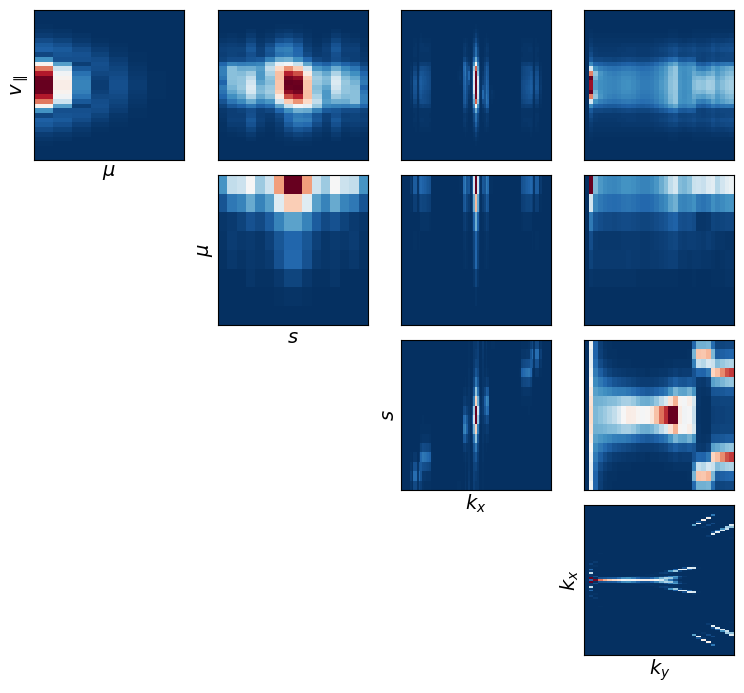

In [9]:
fig = plot_nd(np.abs(np.asarray(fds)))